In [18]:
import numpy as np

# -------------------------------
# Block 1: 光谱网格 + 刺激生成
# -------------------------------

# 光谱范围（nm）
wl_min, wl_max, wl_step = 380, 700, 5
wavelengths = np.arange(wl_min, wl_max + wl_step, wl_step)
n_wl = len(wavelengths)

# 生成高斯窄带光谱
def make_narrow_spectrum(center_nm, width_nm=20.0, peak=1.0):
    sigma = width_nm / 2.355
    return peak * np.exp(-0.5 * ((wavelengths - center_nm) / sigma) ** 2)

# 随机数发生器
rng = np.random.default_rng(42)

# 批次中心波长
def make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680):
    return np.linspace(wl_lo, wl_hi, n_centers)

# 生成刺激 batch
def make_stimuli_batch(centers, n_repeats=6,
                       intensities=(0.5, 0.8),
                       noise_power=0.02):
    batch = []
    for c in centers:
        for peak in intensities:
            for _ in range(n_repeats):
                spec = make_narrow_spectrum(c, width_nm=22, peak=peak)
                spec = np.clip(spec + rng.normal(0, noise_power, size=spec.shape),
                               0, None)
                batch.append({'wl_center': float(c), 'spectrum': spec})
    rng.shuffle(batch)
    return batch

# 实例化一个 batch
centers = make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680)
stim_batch = make_stimuli_batch(centers)

print("Block 1 OK — 刺激 batch 大小:", len(stim_batch))

Block 1 OK — 刺激 batch 大小: 120


In [19]:
# ---------------------------------------------
# Block 2: 受体 bank + pooling（汇聚到簇）
# ---------------------------------------------

# 定义三类受体中心波长（类似 S/M/L cones）
S_center, M_center, L_center = 440, 530, 560   # nm
width = 40.0                                   # nm, 光谱敏感度宽度

# 高斯型敏感曲线
def gaussian_sensitivity(center, width):
    sigma = width / 2.355
    return np.exp(-0.5 * ((wavelengths - center) / sigma) ** 2)

# 生成受体 bank（每组轻微 jitter）
def make_receptor_bank(n_per_group=4, jitter=10.0):
    centers = []
    for base in [S_center, M_center, L_center]:
        centers.extend(base + rng.normal(0, jitter, size=n_per_group))

    sens = np.stack([gaussian_sensitivity(c, width) for c in centers], axis=0)
    sens = sens / (sens.max(axis=1, keepdims=True) + 1e-9)
    return sens, np.array(centers)

# 构建受体矩阵：receptor_sens.shape = [12, n_wl]
receptor_sens, receptor_centers = make_receptor_bank(n_per_group=4, jitter=10.0)

print("Block 2 OK — 受体数量:", receptor_sens.shape[0])

# --------- pooling：把12个受体 → 3个簇（S/M/L）---------

# (0,1,2,3) 属于簇 S
# (4,5,6,7) 属于簇 M
# (8,9,10,11) 属于簇 L
cluster_map = np.array([0]*4 + [1]*4 + [2]*4)
n_clusters = 3

def pool_to_clusters(receptor_acts):
    """
    receptor_acts: [T, n_receptors]
    输出: [T, 3]，每个簇取其成员平均
    """
    T = receptor_acts.shape[0]
    pooled = np.zeros((T, n_clusters))
    for k in range(n_clusters):
        idx = np.where(cluster_map == k)[0]
        pooled[:, k] = receptor_acts[:, idx].mean(axis=1)
    return pooled

print("Block 2 OK — pooling 函数可用")

Block 2 OK — 受体数量: 12
Block 2 OK — pooling 函数可用


In [20]:
# -------------------------------------------------------
# Block 3: 能态模块（光能 + 内部能态 + 受体敏感度调制）
# -------------------------------------------------------

# ---- 物理常数（使用缩放以保持数值稳定） ----
h = 6.626e-34     # Planck 常数
c = 3e8           # 光速
energy_scale = 1e27   # 数值缩放因子

def photon_energy(wavelengths_nm):
    """
    光子能量 E = hc/λ （单位 nm → m）
    输出经过缩放，使其进入可计算范围。
    """
    wavelengths_m = wavelengths_nm * 1e-9
    E = (h * c) / wavelengths_m
    return E * energy_scale


# ---- 内部能态 Energy(t) 的更新规则 ----
def update_energy(E_prev, processing_cost, recovery=0.01):
    """
    E_{t+1} = E_t - cost + recovery
    并限制在 [0, 1]。
    cost 通常与受体活性均值成比例。
    """
    E_new = E_prev - processing_cost + recovery
    return float(np.clip(E_new, 0.0, 1.0))


# ---- 能态调制受体响应 ----
def receptor_response_with_energy(spectrum,
                                  receptor_sens,
                                  wavelengths,
                                  Energy_t):
    """
    输入：
        - spectrum: 原始光谱
        - receptor_sens: [n_receptors, n_wl] 敏感度矩阵
        - Energy_t: 当前内部能态（0~1）

    输出：
        - base: 能态调制后的受体响应（下一步将进入 pooling）
    """

    # 物理能量（光子能）对光谱加权
    photon_E = photon_energy(wavelengths)
    weighted_spec = spectrum * (0.3 + 0.7 * (photon_E / photon_E.max()))

    # 受体基础响应
    base = receptor_sens @ weighted_spec   # shape = [n_receptors]

    # 能态对敏感度锐度的调制：
    # Energy_t 高 → 曲线更锐利
    # Energy_t 低 → 响应变钝 → 颜色区分能力弱
    sharpness = 0.5 + 0.5 * Energy_t      # 0.5~1.0
    base = base ** sharpness

    # 整体增益调制：能态越高，响应越强
    base = base * (0.3 + 0.7 * Energy_t)

    return base

In [22]:
# -------------------------------------------------------
# Block 4: Mitral 动力学 + Opponent Channels（RG/BY/LUM）
# -------------------------------------------------------

def run_mitral_dynamics(cluster_acts, alpha=0.3, inhib=0.4):
    """
    cluster_acts: [T, 3] 对应 S/M/L 三簇汇聚后的输入
    输出：mitral_ts [T, 3] 的动力学演化
    """
    T = cluster_acts.shape[0]

    # 输入权重：简单对角矩阵（可进一步扩展）
    W_in = np.eye(3)

    # 侧抑矩阵：上三角全 1，去掉对角线
    L = inhib * (np.ones((3,3)) - np.eye(3))

    m = np.zeros(3)
    mitral_ts = []

    for t in range(T):
        drive = W_in @ cluster_acts[t]  # 前馈输入
        lateral = L @ m                 # 侧抑部分

        # 连续时间动力系统离散化：m_{t+1} = ...
        m = (1 - alpha) * m + alpha * np.maximum(0, drive - lateral)
        mitral_ts.append(m.copy())

    return np.stack(mitral_ts, axis=0)


# ---- 对手通道（Opponent Channels）----
def opponent_channels(mitral_ts):
    """
    输入：
        mitral_ts: [T, 3] 依次对应 [S, M, L]
    输出：
        RG, BY, LUM 三个中间态通道
    """
    S = mitral_ts[:, 0]
    M = mitral_ts[:, 1]
    L = mitral_ts[:, 2]

    RG  = L - M                          # 红 - 绿 通道
    BY  = 0.5 * (L + M) - S              # 黄 - 蓝 通道
    LUM = L + M + S                      # 亮度

    return {
        'RG': RG,
        'BY': BY,
        'LUM': LUM
    }


print("Block 4 OK — Mitral动力学 + 对手通道 ready.")

Block 4 OK — Mitral动力学 + 对手通道 ready.


In [23]:
# -------------------------------------------------------
# Block 5: BW/COLOR 决策层 + 能态阈值 + 反向塑形
# -------------------------------------------------------

def compute_threshold(Energy_t, base_thresh=0.15):
    """
    决策阈值：
    能态越高 → 阈值越高 → COLOR neuron 允许竞争更久
    能态越低 → 阈值越低 → 系统快速“粗糙判断”
    """
    return base_thresh + 0.20 * Energy_t


def decision_competition_energy(RG, BY, LUM, Energy_seq,
                                alpha_dec=0.25, inhib_dec=0.6):
    """
    输入：
        RG, BY, LUM: 中间态时间序列
        Energy_seq: 内部能态序列（0~1）
    输出：
        BW_ts, COLOR_ts: 二元竞争轨迹
        RG_fb, BY_fb   : 反向塑形后的中间态
    """

    T = len(RG)
    BW = 0.1        # 决策神经元初值
    COLOR = 0.1

    BW_ts = []
    COLOR_ts = []

    # 中间态的反向塑形结果
    RG_fb = RG.copy()
    BY_fb = BY.copy()

    for t in range(T):
        E = Energy_seq[t]

        # ---- 动态阈值 ----
        threshold = compute_threshold(E)

        # ---- 基本驱动 ----
        drive_bw    = (+1.0 * LUM[t] - 0.6 * RG[t] - 0.6 * BY[t])
        drive_color = (+1.2 * RG[t] + 1.2 * BY[t])

        # ---- 能态调制竞争强度 ----
        comp_strength = inhib_dec * (0.5 + 0.5 * E)

        # ---- 动力系统更新（互抑 + ReLU）----
        BW = (1 - alpha_dec)*BW + alpha_dec*np.maximum(0, drive_bw - comp_strength*COLOR)
        COLOR = (1 - alpha_dec)*COLOR + alpha_dec*np.maximum(0, drive_color - comp_strength*BW)

        BW_ts.append(BW)
        COLOR_ts.append(COLOR)

        # ---- 能态反向塑形（关键）----
        # 轨迹深度由能态控制：
        #   E 高 → 允许深轨迹（反馈强）
        #   E 低 → 轨迹被“压扁”（反馈弱）
        feedback_gain = 0.10 + 0.30 * E

        delta = COLOR - BW
        RG_fb[t] = RG[t] + feedback_gain * delta
        BY_fb[t] = BY[t] + feedback_gain * delta

    return np.array(BW_ts), np.array(COLOR_ts), RG_fb, BY_fb


print("Block 5 OK — 决策层（能态 × 阈值 × 反向塑形）ready.")

Block 5 OK — 决策层（能态 × 阈值 × 反向塑形）ready.


In [24]:
# -------------------------------------------------------
# Block 6: Energy Pipeline（受体 → pooling → mitral → 决策）
# -------------------------------------------------------

def run_energy_pipeline(spectrum,
                        receptor_sens,
                        wavelengths,
                        T=40,
                        alpha=0.3,
                        inhib=0.4,
                        gate=None):
    """
    输入：
        spectrum: 光谱向量
        receptor_sens: 受体 bank
        wavelengths: 光谱轴
        gate: 相位门控（phase_gate）

    输出：
        RG, BY, RG_fb, BY_fb: 中间态（原始 vs 能态反向塑形）
        BW, COLOR: 决策轨迹
        Energy_ts: 能态轨迹
    """

    if gate is None:
        gate = np.ones(T)

    # ---------- (1) 受体层（含能态） ----------
    receptor_ts = []
    Energy_ts = []
    E_t = 1.0     # 初始能态

    for t in range(T):
        # 能态调制受体响应
        base = receptor_response_with_energy(
            spectrum,
            receptor_sens,
            wavelengths,
            E_t
        )

        # 加入相位门控
        receptor_ts.append(base * gate[t])

        # 能态消耗模型：受体平均激活越高 → cost 越高
        processing_cost = 0.02 * np.mean(base)
        E_t = update_energy(E_t, processing_cost)
        Energy_ts.append(E_t)

    receptor_ts = np.stack(receptor_ts, axis=0)   # [T, n_receptors]


    # ---------- (2) pooling 受体 → 3簇 ----------
    cluster_acts = pool_to_clusters(receptor_ts)   # [T, 3]


    # ---------- (3) mitral 动力学 ----------
    mitral_ts = run_mitral_dynamics(cluster_acts,
                                    alpha=alpha,
                                    inhib=inhib)


    # ---------- (4) opponent 通道 ----------
    opp = opponent_channels(mitral_ts)
    RG  = opp['RG']
    BY  = opp['BY']
    LUM = opp['LUM']


    # ---------- (5) 决策层（能态 × 阈值 × 反向塑形） ----------
    BW, COLOR, RG_fb, BY_fb = decision_competition_energy(
        RG, BY, LUM, Energy_ts
    )


    # ---------- 输出 ----------
    return RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts


print("Block 6 OK — Energy Pipeline ready.")

Block 6 OK — Energy Pipeline ready.


In [25]:
# -------------------------------------------------------
# Block 7: 可视化三联图（中间态 / 决策 / 能态）
# -------------------------------------------------------

import matplotlib.pyplot as plt

def plot_energy_trajectory(RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts,
                           title="Energy Model Trajectory"):

    T = len(RG)
    t = np.arange(T)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ---- (1) RG-BY 轨迹 ----
    ax = axes[0]
    ax.plot(RG, BY, 'o--', alpha=0.4, label='原始轨迹')
    ax.plot(RG_fb, BY_fb, 'o-', alpha=0.9, label='能态反向塑形')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel("RG (红-绿)")
    ax.set_ylabel("BY (黄-蓝)")
    ax.set_title("中间态轨迹（能态影响）")
    ax.legend()

    # ---- (2) BW/COLOR 决策轨迹 ----
    ax = axes[1]
    ax.plot(t, BW, label='BW neuron')
    ax.plot(t, COLOR, label='COLOR neuron')
    ax.set_xlabel("time")
    ax.set_ylabel("activation")
    ax.set_title("二元决策轨迹")
    ax.legend()

    # ---- (3) 能态 Energy(t) ----
    ax = axes[2]
    ax.plot(t, Energy_ts, color='green')
    ax.set_xlabel("time")
    ax.set_ylabel("Energy(t)")
    ax.set_title("内部能态随时间变化")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Block 7 OK — Plotting module ready.")

Block 7 OK — Plotting module ready.


In [26]:
# ---- 确保 phase_gate 已定义 ----
def make_phase_gate(T=40, freq=1.0, phase=0.0):
    t = np.arange(T)
    gate = np.sin(2*np.pi*(freq*t/T) + phase)**2
    gmin, gmax = gate.min(), gate.max()
    return 0.1 + 0.9*(gate - gmin)/(gmax - gmin + 1e-9)

phase_gate = make_phase_gate(T=40)
print("phase_gate initialized:", phase_gate.shape)

phase_gate initialized: (40,)


C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 32511 (\N{CJK UNIFIED IDEOGRAPH-7EFF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 40644 (\N{CJK UNIFIED IDEOGRAPH-9EC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 34013 (\N{CJK UNIFIED IDEOGRAPH-84DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_29360\2638979631.py:43: UserWarning: Glyph 38388 (\

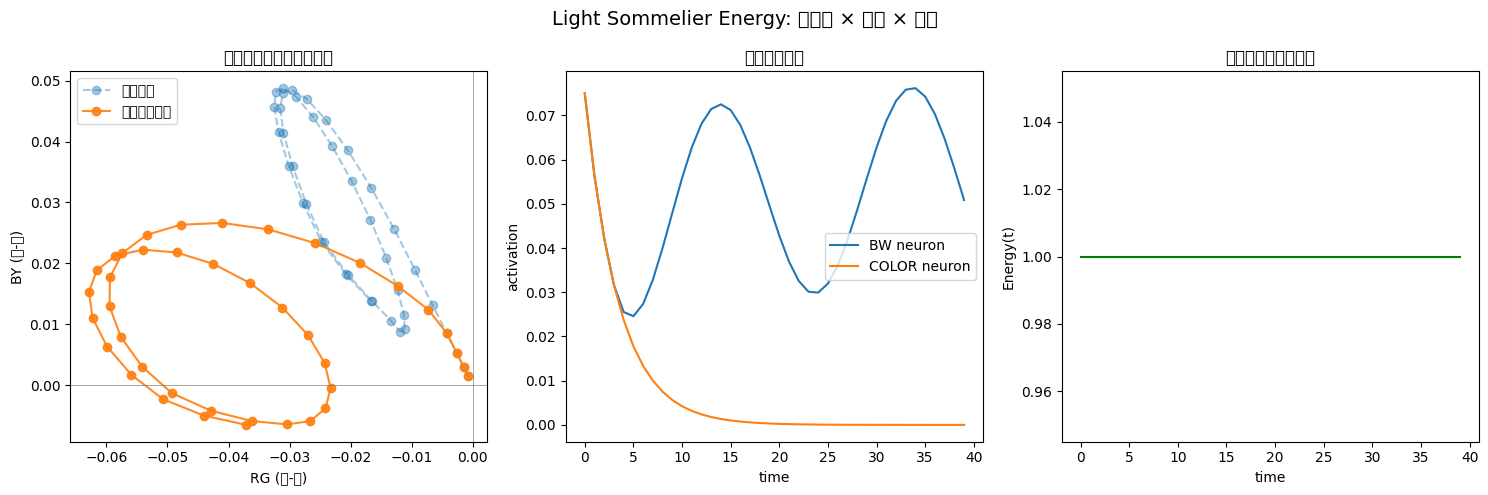

In [27]:
# -------------------------------------------------------
# Block 8: 试跑示例（完整 Energy Pipeline）
# -------------------------------------------------------

# 从刺激 batch 中取一条样本光谱
sample = stim_batch[0]['spectrum']

# 跑完整能态模型
RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts = run_energy_pipeline(
    sample,
    receptor_sens,
    wavelengths,
    T=len(phase_gate),
    gate=phase_gate
)

# 三联图可视化
plot_energy_trajectory(
    RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts,
    title="Light Sommelier Energy: 中间态 × 决策 × 能态"
)